# GeoExplain: end-to-end workflow

**Explainable machine learning for geospatial prediction: which variables matter, and *where*.**

This notebook walks through: data → validation → model → evaluation → SHAP → **spatial SHAP** → maps → export.

> All data are **synthetic** (generated by GeoExplain, see `data/README.md`). Numbers illustrate the workflow; they are not real-world results. SHAP describes *model behaviour* (association/prediction), not causal effects.

Run `python reproduce.py` (or `geoxplain generate-data --out-dir data`) from the repository root first if `data/samples.csv` is missing.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from geoxplain import (GeoExplainModel, GeoShapExplainer, compute_spatial_shap, load_dataset,
                       read_raster_stack, spatial_split, permutation_importance)
from geoxplain.datasets import FEATURE_LABELS
from geoxplain.validation import random_split, compare_validation_strategies
from geoxplain import visualization as viz

plt.rcParams["figure.dpi"] = 90
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (ROOT / "data" / "samples.csv").exists(), "Generate the data first: geoxplain generate-data --out-dir data"
OUT = ROOT / "outputs" / "notebook"; OUT.mkdir(parents=True, exist_ok=True)

## 1. Load and inspect the dataset

In [2]:
FEATURES = ["ndvi", "ndbi", "lst", "elevation", "rainfall", "distance_to_water", "population"]
ds = load_dataset(ROOT / "data" / "samples.csv", target="target", features=FEATURES, crs="EPSG:32645")
print(ds.summary()["class_counts"], "| observations:", len(ds.X))
ds.X.describe().round(2)

{'0': 1764, '1': 736} | observations: 2500


,ndvi,ndbi,lst,elevation,rainfall,distance_to_water,population
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,0.54,-0.06,28.47,11.76,1902.63,580.03,596.31
std,0.20,0.15,1.69,5.30,219.76,387.90,669.02
min,-0.27,-0.45,22.21,0.50,1384.02,0.00,0.00
25%,0.49,-0.16,27.41,8.40,1767.24,252.77,216.37
50%,0.58,-0.07,28.43,12.61,1913.73,540.83,379.95
75%,0.65,0.03,29.59,15.56,2066.45,890.45,679.42
max,0.84,0.35,32.52,22.28,2312.66,1542.89,4659.59


## 2. Why spatial validation? Random vs spatial hold-out

Nearby observations are similar (spatial autocorrelation), so a random split can be optimistic for prediction in *new areas*. We compare both.

In [3]:
results = {}
for name, (tr, te) in {"random hold-out": random_split(len(ds.X), 0.25, 42, stratify=ds.y.to_numpy()),
                       "spatial hold-out": spatial_split(ds.require_coords(), 0.25, random_state=42)}.items():
    m = GeoExplainModel("random_forest", "classification", random_state=42).fit(ds.X.iloc[tr], ds.y.iloc[tr])
    results[name] = m.evaluate(ds.X.iloc[te], ds.y.iloc[te])
pd.DataFrame(results).T[["accuracy", "f1", "roc_auc", "pr_auc"]].round(3)

,accuracy,f1,roc_auc,pr_auc
random hold-out,0.792,0.567,0.831,0.694
spatial hold-out,0.776,0.321,0.787,0.567


In [4]:
cv = compare_validation_strategies(GeoExplainModel("random_forest", "classification"), ds, n_splits=5)
cv.optimism().round(3)

,random_kfold,spatial_block_cv,difference
metric,,,
accuracy,0.792,0.770,0.022
balanced_accuracy,0.713,0.653,0.060
precision,0.699,0.651,0.048
recall,0.520,0.381,0.139
f1,0.596,0.478,0.118
roc_auc,0.837,0.771,0.066
pr_auc,0.719,0.617,0.102


## 3. Train the final model and compute global explanations

In [5]:
model = GeoExplainModel("random_forest", "classification", random_state=42).fit(ds.X, ds.y)
explainer = GeoShapExplainer(model, background=ds.X.sample(100, random_state=0))
sv = explainer.explain(ds.X.sample(400, random_state=0))
print("output space:", sv.output_space, "| additivity:", explainer.check_additivity(sv))
sv.mean_abs().round(4)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


output space: probability | additivity: {'max_abs_error': 4.884981308350689e-15, 'mean_abs_error': 7.628454617124303e-16, 'ok': True}


,feature,mean_abs_shap,share,rank
0,distance_to_water,0.0992,0.2893,1
1,rainfall,0.0663,0.1933,2
2,elevation,0.0567,0.1653,3
3,lst,0.0388,0.1131,4
4,ndbi,0.0351,0.1022,5
5,ndvi,0.0261,0.0762,6
6,population,0.0207,0.0605,7


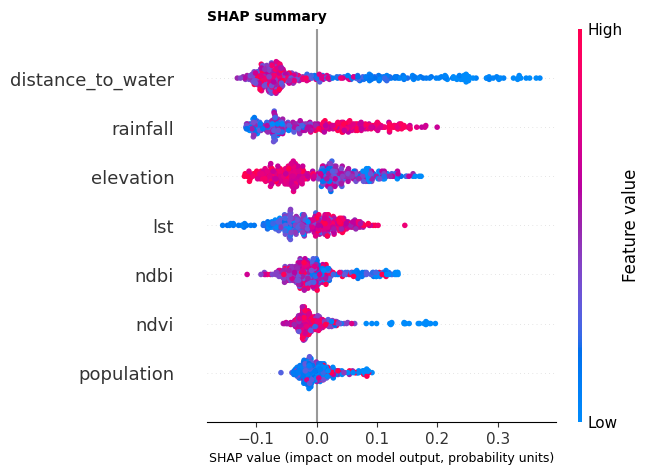

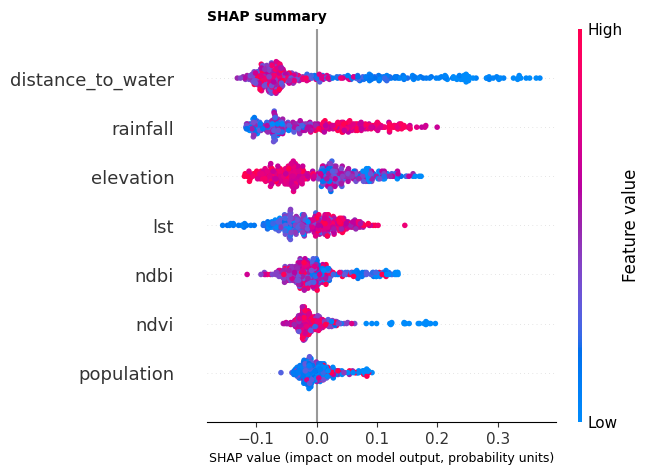

In [6]:
viz.plot_shap_summary(sv)

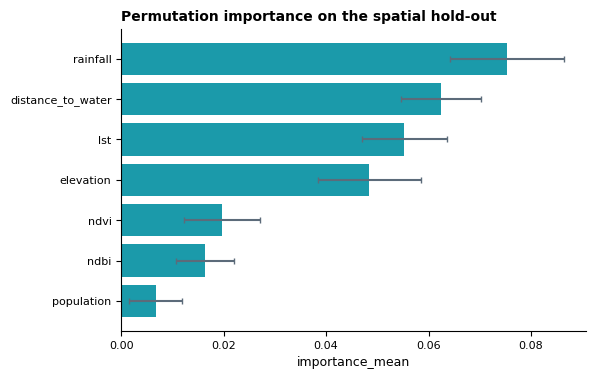

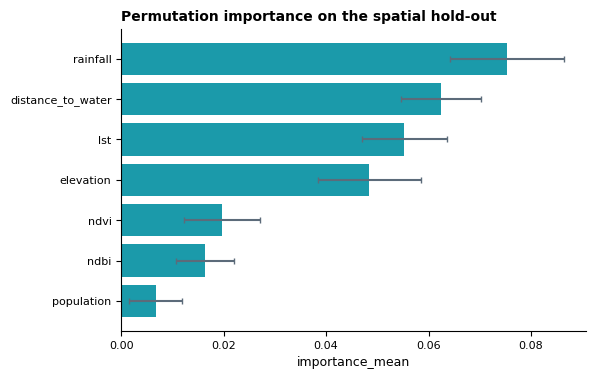

In [7]:
tr, te = spatial_split(ds.require_coords(), 0.25, random_state=42)
holdout = GeoExplainModel("random_forest", "classification", random_state=42).fit(ds.X.iloc[tr], ds.y.iloc[tr])
perm = permutation_importance(holdout, ds.X.iloc[te], ds.y.iloc[te], n_repeats=10)
viz.plot_importance(perm, title="Permutation importance on the spatial hold-out")

## 4. Local explanation of a single observation

             feature     value   shap
0          elevation    16.392 -0.076
1               ndbi    -0.033 -0.055
2               ndvi     0.592 -0.031
3           rainfall  2222.844  0.030
4         population   406.496 -0.018
5                lst    28.169 -0.013
6  distance_to_water   339.411  0.005


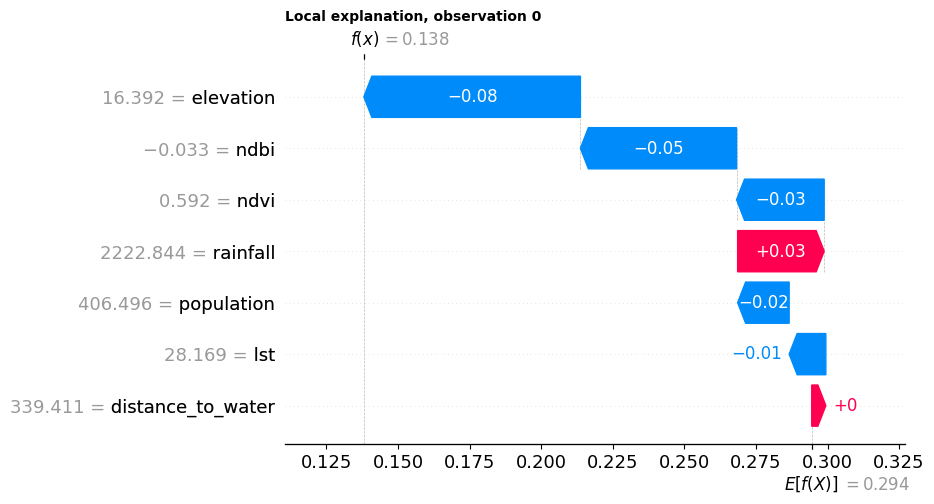

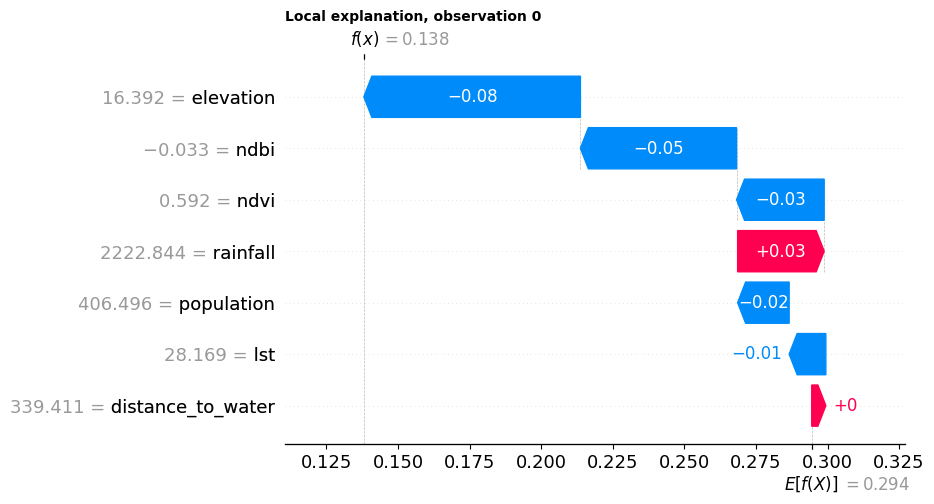

In [8]:
print(sv.local(0).round(3))
viz.plot_waterfall(sv, 0)

## 5. Spatial SHAP: *where* do the features matter?

SHAP values are computed for every valid raster cell and written back to the same cell. CRS, transform, size and nodata are preserved.

In [9]:
stack = read_raster_stack(ROOT / "data" / "stack.tif")
res = compute_spatial_shap(model, stack, background=ds.X.sample(100, random_state=0), feature_labels=FEATURE_LABELS)
written = res.write(OUT / "rasters")
print(sorted(p.name for p in written.values()))
res.summary_table().round(4)

['DistanceToWater_SHAP.tif', 'Elevation_SHAP.tif', 'LST_SHAP.tif', 'NDBI_SHAP.tif', 'NDVI_SHAP.tif', 'Population_SHAP.tif', 'Rainfall_SHAP.tif', 'SHAP_sum.tif', 'dominant_driver.tif', 'prediction.tif', 'prediction_class.tif', 'spatial_shap_metadata.json', 'uncertainty.tif']


,feature,mean_shap,std_shap,min_shap,max_shap,mean_abs_shap,share_cells_positive,share_cells_dominant
0,distance_to_water,0.0105,0.1203,-0.1342,0.3770,0.0958,0.3521,0.4558
1,rainfall,-0.0020,0.0737,-0.1484,0.2009,0.0644,0.4776,0.2641
2,elevation,0.0025,0.0629,-0.1255,0.1735,0.0539,0.5246,0.1843
3,lst,-0.0087,0.0475,-0.1698,0.1600,0.0382,0.4715,0.0471
4,ndbi,-0.0024,0.0488,-0.1275,0.1380,0.0371,0.3474,0.0311
5,ndvi,0.0005,0.0463,-0.0562,0.2091,0.0274,0.2832,0.0172
6,population,0.0012,0.0285,-0.0644,0.0975,0.0210,0.4146,0.0004


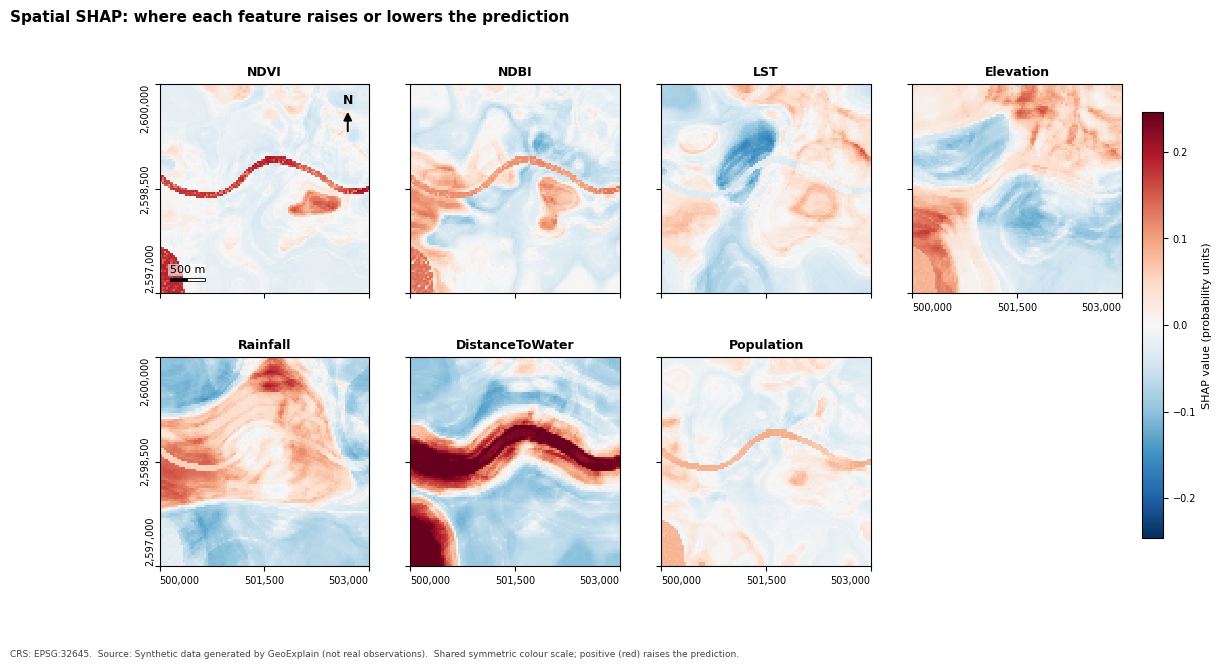

In [10]:
viz.plot_shap_panels(res)

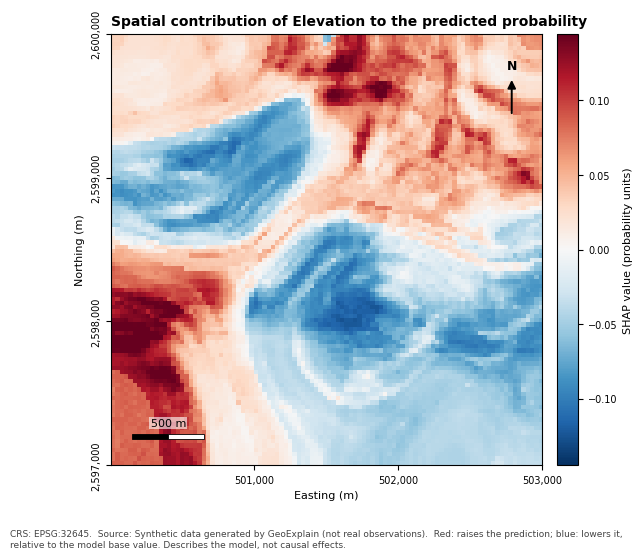

In [11]:
viz.plot_shap_map(res, 'elevation')

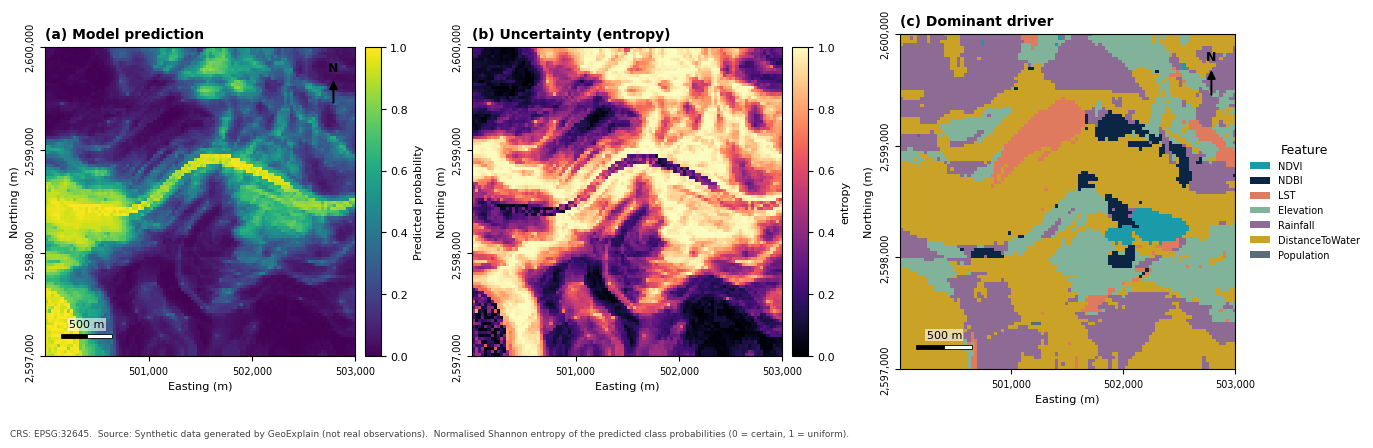

In [12]:
viz.plot_prediction_uncertainty(res)

## 6. Verify georeferencing and additivity

In [13]:
import rasterio
with rasterio.open(written["NDVI_SHAP"]) as r:
    print("CRS equal:", r.crs == stack.crs, "| transform equal:", r.transform == stack.transform,
          "| shape equal:", (r.height, r.width) == stack.shape, "| nodata:", r.nodata)
print("cell-wise additivity:", res.additivity)

CRS equal: True | transform equal: True | shape equal: True | nodata: -9999.0
cell-wise additivity: {'max_abs_error': 4.884981308350689e-15, 'mean_abs_error': 7.815696874413635e-16, 'ok': True}


## 7. Interpretation checklist

* SHAP values are **model** contributions relative to a base value: association and prediction, not causal effects.
* Correlated predictors share credit; check dependence plots and domain knowledge.
* Spatial SHAP is computed per cell; it flags where the model uses a feature, not why the world behaves so.
* Uncertainty layers are model-based spreads, not calibrated intervals.

See `docs/limitations.md` and `docs/methodology.md`.